## Setup and Configuration

In [33]:
import numpy as np
import os
import pandas as pd
from itertools import product
from collections import defaultdict
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Add project root to path
ROOT = Path.cwd().parents[1]  # Assumes notebook is in projects/MOSAIC/notebooks/
sys.path.append(str(ROOT))
sys.path.append(str(ROOT / "src"))

# Import MOSAIC-specific utilities
from pose_dynamics.projects.MOSAIC import (
    extract_keypoints,
    load_mosaic_session,
    load_trial_info,
    extract_audio_conditions,
    preprocess_mosaic_trial,
    get_window_indices,
    build_symmetric_template,
    compute_reference_limb_lengths,
    batch_apply_fixed_lengths,
    align_keypoints,
    rebuild_aligned_dataframe,
    add_custom_features,
    compute_velocity,
    compute_linear_metrics
)

from pose_dynamics.projects.MOSAIC.alignment import order_xy_pairs
from pose_dynamics.projects.MOSAIC.visualization import (
    plot_alignment_diagnostics
)

# Import shared utilities
from pose_dynamics.preprocessing import (
    normalize_by_resolution,
    mask_low_confidence,
    interpolate_nans,
    filter_data_safe_preserve_nans
)

# Import RQA utilities (C++ backend compiled and ready)
from pose_dynamics.nonlinear.rqa_utils import cross_rqa, auto_rqa, make_rqa_params

print("✓ Imports successful")

✓ Imports successful


## Parameters

In [34]:
# === Data Configuration ===
DATA_PATH = "G:/mosaic analysis files"  # Update to your data path
KEYPOINT_SETS = [["center_face", "body", "arm"]]

# === Processing Parameters ===
CONF_THRESHOLD = 0.4
MAX_INTERP_GAP = 60
FILTER_CUTOFF = 10.0
FILTER_ORDER = 4
FPS = 60

# === Window Parameters ===
WINDOW_SIZE_RQA = 60 * 60      # 60 seconds for RQA/CRQA
WINDOW_SIZE_LINEAR = 5 * 60    # 5 seconds for linear metrics
WINDOW_OVERLAP = 0.5

# === RQA/CRQA Parameters ===
TIME_LAGS = [15]
EMBEDDING_DIMS = [4]
RADII = [0.15]

# === Alignment Parameters ===
SYMMETRIZATION_MODE = "none"  # Options: "none", "nose", "torso", "full"
ALLOW_ROTATION = True
USE_VELOCITY = False  # Set True to analyze velocity instead of position

# === Session Selection ===
SKIP_SESSIONS = [1]  # Sessions to skip

# === Output Directories ===
os.makedirs("../crqa_results", exist_ok=True)
os.makedirs("../rqa_results", exist_ok=True)
os.makedirs("../linear_results", exist_ok=True)
os.makedirs("../animations", exist_ok=True)

print("✓ Parameters configured")

✓ Parameters configured


## Helper Functions

In [35]:
def safe_get(dct, key):
    """Safely extract value from dict, return NaN if missing."""
    return dct.get(key, np.nan) if dct else np.nan


def display_summary(trials, expected_cols):
    """Display summary statistics for loaded data."""
    n_trials = len(trials)
    sessions = {meta['Session'] for _, meta in trials}
    conditions = {meta['Condition'] for _, meta in trials}
    roles = {meta['Role'] for _, meta in trials}
    
    print(f"\n{'='*60}")
    print("DATA SUMMARY")
    print(f"{'='*60}")
    print(f"Total trials loaded:      {n_trials}")
    print(f"Sessions:                 {len(sessions)} (S{min(sessions):03} - S{max(sessions):03})")
    print(f"Unique conditions:        {len(conditions)} {sorted(conditions)}")
    print(f"Roles:                    {sorted(roles)}")
    print(f"Keypoints per trial:      {len(expected_cols) // 2}")
    print(f"{'='*60}\n")

In [36]:
# === ROI (Region of Interest) Definitions ===

def get_roi_definitions(expected_cols):
    """Define ROIs by keypoint names, dynamically resolved to column indices.
    
    This function maps loaded keypoints (from KEYPOINT_SETS) to named ROIs.
    ROI membership is determined by keypoint name patterns, not hardcoded indices.
    
    Args:
        expected_cols: List of column names from loaded keypoints
        
    Returns:
        dict: ROI names mapped to lists of column pairs [(x_col, y_col), ...]
    """
    roi_definitions = {
        'centre_face': {
            'keypoint_patterns': ['Eye', 'Pupil', 'Chin', 'Nostril', 'Lip', 'Nose']
        },
        'upper_body': {
            'keypoint_patterns': ['Shoulder', 'Neck']
        },
        'arms': {
            'keypoint_patterns': ['Shoulder', 'Elbow', 'Wrist']
        }
    }
    
    # Resolve column names based on patterns
    resolved_rois = {}
    for roi_name, spec in roi_definitions.items():
        patterns = spec['keypoint_patterns']
        roi_cols = []
        
        # Match columns by keypoint name patterns
        for col in expected_cols:
            # Skip confidence columns
            if col.endswith('_confidence'):
                continue
            # Check if column matches any pattern for this ROI
            for pattern in patterns:
                if pattern in col:
                    # Get corresponding x, y pair
                    col_base = col.replace('_x_offset', '').replace('_y_offset', '')
                    x_col = col_base + '_x_offset'
                    y_col = col_base + '_y_offset'
                    if x_col in expected_cols and y_col in expected_cols:
                        if (x_col, y_col) not in roi_cols:
                            roi_cols.append((x_col, y_col))
                    break
        
        resolved_rois[roi_name] = roi_cols
    
    return resolved_rois


def extract_roi_keypoints(df, roi_name, roi_definitions):
    """Extract keypoints for a specific ROI from a dataframe.
    
    Args:
        df: DataFrame with ROI keypoint columns
        roi_name: Name of ROI ('centre_face', 'upper_body', or 'arms')
        roi_definitions: Dictionary from get_roi_definitions() - maps ROI names to column pairs
    
    Returns:
        dict: {'cols': list of (x, y) column pairs for this ROI}
    """
    if roi_name not in roi_definitions:
        raise ValueError(f"Unknown ROI: {roi_name}")
    
    roi_cols = roi_definitions[roi_name]
    
    return {
        'cols': roi_cols
    }


def collapse_roi_to_vectors(df, roi_info):
    """Collapse ROI keypoints into a single magnitude vector via centroid.
    
    For each frame, computes:
    - ROI centroid: mean (x, y) across all keypoints in the ROI
    - Magnitude vector: Euclidean norm of the centroid position
    
    Args:
        df: DataFrame with ROI keypoint columns
        roi_info: Output from extract_roi_keypoints()
    
    Returns:
        dict: {
            'magnitude': (n_frames, 1) array of centroid magnitudes
        }
    """
    roi_cols = roi_info['cols']
    
    if not roi_cols:
        raise ValueError("No keypoints found in ROI")
    
    # Compute centroid position (mean x, y across all keypoints)
    x_cols = [x_col for x_col, y_col in roi_cols]
    y_cols = [y_col for x_col, y_col in roi_cols]
    
    centroid_x = df[x_cols].mean(axis=1).values
    centroid_y = df[y_cols].mean(axis=1).values
    
    # Compute magnitude of centroid
    magnitude_vector = np.sqrt(centroid_x**2 + centroid_y**2).reshape(-1, 1)
    
    return {
        'magnitude': magnitude_vector
    }


## Pass 1: Load Data and Build Global Template

This pass:
1. Loads all session/trial pose files
2. Extracts relevant keypoints
3. Preprocesses (normalize, mask, interpolate, filter)
4. Slices into windows
5. Builds global symmetric template from all data

In [37]:
raw_windows = []   # (window_df, metadata)
full_trials = []   # for template building
expected_cols = None

print("Loading and preprocessing data...")

for session_number in range(2, 3):
    if session_number in SKIP_SESSIONS:
        print(f"[SKIP] Session {session_number:03} (user request)")
        continue

    # Load trial info
    trial_info = load_trial_info(DATA_PATH, session_number)
    if trial_info is None:
        continue
    
    audio_conditions = extract_audio_conditions(trial_info)

    for trial_number in range(1, 7):
        for role, suffix in [("Left", "left"), ("Right", "right")]:
            # Load pose data
            data = load_mosaic_session(DATA_PATH, session_number, trial_number, suffix)
            if data is None:
                continue

            # Extract keypoints
            selected = extract_keypoints(data, sets=KEYPOINT_SETS[0])
            
            # Get expected columns from first valid trial
            if expected_cols is None and not selected.empty:
                expected_cols = order_xy_pairs(selected.columns)
                print(f"✓ Column order established: {len(expected_cols)} columns ({len(expected_cols)//2} keypoints)")
            
            # Preprocess
            try:
                preprocessed = preprocess_mosaic_trial(
                    selected,
                    expected_cols,
                    conf_threshold=CONF_THRESHOLD,
                    max_interp_gap=MAX_INTERP_GAP,
                    filter_cutoff=FILTER_CUTOFF,
                    filter_order=FILTER_ORDER,
                    fps=FPS
                )
                
                # Keep full trial for template
                full_trials.append(preprocessed)
                
                # Create windows
                for ws in [WINDOW_SIZE_RQA]:
                    win_indices = get_window_indices(len(preprocessed), ws, WINDOW_OVERLAP)
                    for w_idx, (start, end) in enumerate(win_indices):
                        window = preprocessed.iloc[start:end].reset_index(drop=True)
                        
                        meta = {
                            'Session': session_number,
                            'Trial': trial_number,
                            'Role': role,
                            'Condition': audio_conditions[trial_number - 1],
                            'Window_Size': ws,
                            'Window_Index': w_idx
                        }
                        
                        # Check for NaNs
                        if window.isnull().any().any() or len(window) < ws:
                            raw_windows.append((None, meta))
                        else:
                            raw_windows.append((window, meta))
                            
            except Exception as e:
                print(f"Error processing S{session_number:03} T{trial_number} {role}: {e}")
                continue

print(f"\n✓ Loaded {len([w for w, _ in raw_windows if w is not None])} valid windows from {len(full_trials)} trials")

# Build global template
if not full_trials:
    raise ValueError("No valid trials found for template building")

X_raw = pd.concat(full_trials, ignore_index=True).dropna().astype(np.float32)
global_template = build_symmetric_template(X_raw, expected_cols, mode=SYMMETRIZATION_MODE)
print(f"✓ Global template built: {global_template.shape} with mode='{SYMMETRIZATION_MODE}'")

# Compute reference limb lengths
ref_lengths = None if SYMMETRIZATION_MODE == "nose" else compute_reference_limb_lengths(global_template, expected_cols)
if ref_lengths:
    print(f"✓ Reference limb lengths computed: {len(ref_lengths)} segments")

Loading and preprocessing data...
✓ Column order established: 124 columns (62 keypoints)

✓ Loaded 121 valid windows from 12 trials
✓ Global template built: (62, 2) with mode='none'
✓ Reference limb lengths computed: 4 segments


## Alignment Diagnostics

Visualize alignment quality by comparing raw, aligned, and limb-rescaled poses.

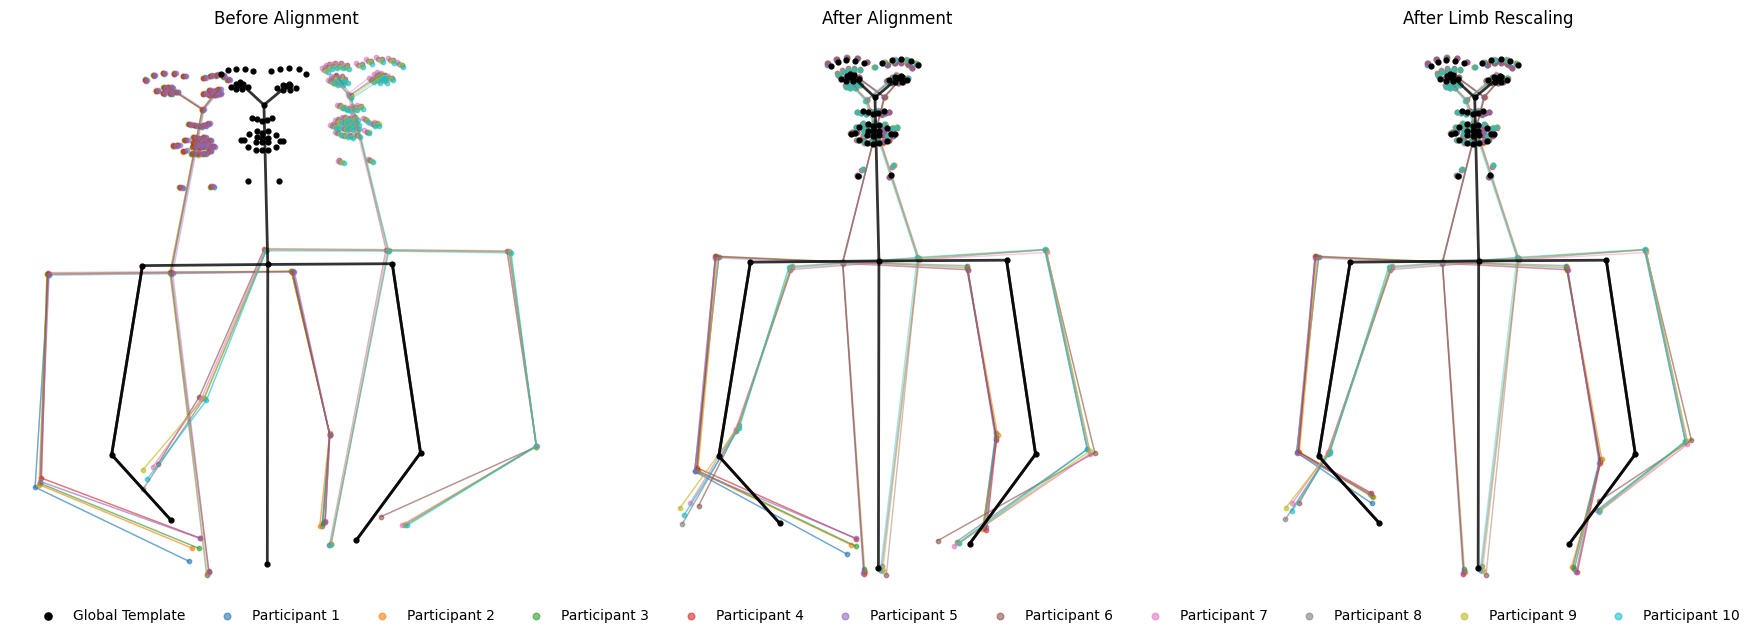

In [38]:
# Sample windows from both Left and Right roles for better visualization
valid_windows = [w for w in raw_windows if w[0] is not None]

# Separate by role
left_windows = [(w, m) for w, m in valid_windows if m['Role'] == 'Left']
right_windows = [(w, m) for w, m in valid_windows if m['Role'] == 'Right']

# Take samples from each role
sample_windows = []
n_per_role = 5
if left_windows:
    sample_windows.extend(left_windows[:n_per_role])
if right_windows:
    sample_windows.extend(right_windows[:n_per_role])

plot_alignment_diagnostics(
    global_template=global_template,
    raw_windows=sample_windows,
    expected_cols=expected_cols,
    align_keypoints=align_keypoints,
    n_samples=len(sample_windows),
    procrustes=True,
    allow_rotation=ALLOW_ROTATION,
    ref_lengths=ref_lengths,
    reference="Torso"
)

## Pass 2: Align Windows and Prepare for Analysis

This pass:
1. Aligns all windows to global template using Procrustes
2. Applies limb length constraints
3. Optionally computes velocity
4. Centers data per trial (removes camera angle effects)

In [39]:
aligned_windows = []
metadata = []

print("Aligning windows...")

for window, meta in raw_windows:
    if window is None:
        aligned_windows.append(None)
        metadata.append(meta)
        continue

    # Align to global template
    aligned_X, _ = align_keypoints(
        window, expected_cols,
        reference="Torso" if SYMMETRIZATION_MODE != "nose" else "Nose",
        template=global_template,
        use_procrustes=True,
        allow_rotation=ALLOW_ROTATION,
        allow_scale=True
    )

    # Apply limb length constraints (matching old code)
    poses = aligned_X.reshape(-1, len(expected_cols)//2, 2)
    if ref_lengths:
        poses = batch_apply_fixed_lengths(poses, ref_lengths)

    # Rebuild DataFrame
    aligned_df = rebuild_aligned_dataframe(
        poses.reshape(-1, len(expected_cols)), expected_cols
    )

    # Optionally compute velocity
    if USE_VELOCITY:
        aligned_df = compute_velocity(aligned_df, fps=FPS)

    aligned_windows.append(aligned_df)
    metadata.append(meta)

print(f"✓ Aligned {len([w for w in aligned_windows if w is not None])} windows")

# Trial-centered normalization (removes camera angle effects)
trial_groups = defaultdict(list)
for i, meta in enumerate(metadata):
    if aligned_windows[i] is None:
        continue
    key = (meta['Session'], meta['Trial'], meta['Role'])
    trial_groups[key].append((i, aligned_windows[i]))

trial_centered_windows = [None] * len(aligned_windows)
for indices_and_data in trial_groups.values():
    trial_df = pd.concat([df for _, df in indices_and_data], ignore_index=True)
    trial_mean = trial_df.mean()
    for idx, df in indices_and_data:
        trial_centered_windows[idx] = df - trial_mean

print("✓ Trial-centered normalization complete")

Aligning windows...
✓ Aligned 121 windows
✓ Trial-centered normalization complete


## ROI-based (C)RQA Analysis

Analyze interpersonal coordination and individual temporal structure using collapsed vectors from three regions of interest (ROIs):
- **Centre-face**: Central facial and head region
- **Upper body**: Torso and shoulder region
- **Arms**: Upper and lower arm movements

For each ROI and participant, we extract both position and magnitude vectors for analysis.


In [40]:
# Initialize ROI definitions from loaded keypoints
roi_definitions = get_roi_definitions(expected_cols)
roi_names = list(roi_definitions.keys())

# Extract ROI vectors for all aligned windows
roi_windows = {roi_name: [] for roi_name in roi_names}
roi_metadata = {roi_name: [] for roi_name in roi_names}

print("Extracting collapsed ROI vectors...")

for window, meta in zip(aligned_windows, metadata):
    if window is None:
        for roi_name in roi_names:
            roi_windows[roi_name].append(None)
            roi_metadata[roi_name].append(meta)
        continue
    
    for roi_name in roi_names:
        # Extract ROI keypoint information
        roi_info = extract_roi_keypoints(window, roi_name, roi_definitions)
        
        # Trial-center the window first (remove camera angle effects)
        window_centered = window - window.mean()
        
        # Collapse to magnitude vector
        try:
            roi_vectors = collapse_roi_to_vectors(window_centered, roi_info)
            
            # Store magnitude vector
            meta_roi = meta.copy()
            meta_roi['roi_magnitude'] = roi_vectors['magnitude']
            meta_roi['roi_n_dims'] = roi_vectors['magnitude'].shape[1]
            
            roi_windows[roi_name].append(window_centered)
            roi_metadata[roi_name].append(meta_roi)
            
        except Exception as e:
            print(f"Error extracting {roi_name} from S{meta['Session']:03} T{meta['Trial']} {meta['Role']}: {e}")
            roi_windows[roi_name].append(None)
            roi_metadata[roi_name].append(meta)

# Display diagnostic information
print(f"\n{'='*60}")
print("ROI EXTRACTION DIAGNOSTICS")
print(f"{'='*60}")

for roi_name in roi_names:
    valid_count = sum(1 for m in roi_metadata[roi_name] if 'roi_magnitude' in m)
    
    if valid_count > 0:
        sample_meta = next(m for m in roi_metadata[roi_name] if 'roi_magnitude' in m)
        n_dims = sample_meta['roi_n_dims']
        
        print(f"\n{roi_name.upper()}")
        print(f"  Valid windows: {valid_count}")
        print(f"  Magnitude vector dimensions: {n_dims}")

print(f"{'='*60}\n")


Extracting collapsed ROI vectors...

ROI EXTRACTION DIAGNOSTICS

CENTRE_FACE
  Valid windows: 121
  Magnitude vector dimensions: 1

UPPER_BODY
  Valid windows: 121
  Magnitude vector dimensions: 1

ARMS
  Valid windows: 121
  Magnitude vector dimensions: 1



## CRQA Analysis: Dyadic Coordination (ROI Magnitude Vectors)

Analyze interpersonal coordination between Left and Right participants using cross-recurrence on collapsed magnitude vectors from each ROI.


In [41]:
# Analyze CRQA for each ROI using magnitude vectors only
vector_types = ['magnitude']

for roi_name in roi_names:
    print(f"\n{'='*60}")
    print(f"CRQA ANALYSIS: {roi_name.upper()}")
    print(f"{'='*60}")
    
    for vector_type in vector_types:
        csv_rows = []
        
        # Group windows by trial (to pair Left/Right)
        paired_windows = defaultdict(dict)
        for meta in roi_metadata[roi_name]:
            if f'roi_{vector_type}' not in meta:
                continue
                
            key = (meta['Session'], meta['Trial'], meta['Window_Index'])
            paired_windows[key][meta['Role']] = meta
        
        print(f"\nRunning CRQA on {vector_type} vectors ({len(paired_windows)} pairs)...")
        
        for key, pair in paired_windows.items():
            if "Left" in pair and "Right" in pair:
                left_meta, right_meta = pair["Left"], pair["Right"]
                left_vector = left_meta[f'roi_{vector_type}']
                right_vector = right_meta[f'roi_{vector_type}']
                
                if left_vector is None or right_vector is None:
                    continue
                
                # Analyze each dimension independently
                n_dims = left_vector.shape[1]
                
                for lag, emb_dim, rad in product(TIME_LAGS, EMBEDDING_DIMS, RADII):
                    for dim_idx in range(n_dims):
                        # Prepare CRQA parameters
                        params = make_rqa_params(
                            eDim=emb_dim,
                            tLag=lag,
                            radius=rad,
                            norm="zscore",
                            rescaleNorm=1,
                            tw=0,  # No Theiler window for cross-RQA
                            minl=2
                        )
                        
                        # Run CRQA
                        try:
                            td, rs, mats, err_code = cross_rqa(
                                left_vector[:, dim_idx],
                                right_vector[:, dim_idx],
                                params,
                                return_mats=False
                            )
                            
                            if dim_idx == 0:  # Print progress for first dimension
                                rec_val = rs.get('perc_recur', np.nan)
                                print(f"[CRQA] S{key[0]:03} T{key[1]} W{key[2]} {vector_type} Dim0 -> REC={rec_val:.2f}%")
                            
                            csv_rows.append({
                                'Session': key[0],
                                'Trial': key[1],
                                'Condition': left_meta['Condition'],
                                'Window_Size': left_meta['Window_Size'],
                                'Window_Index': key[2],
                                'ROI': roi_name,
                                'Vector_Type': vector_type,
                                'Lag': lag,
                                'Embedding_Dim': emb_dim,
                                'Radius': rad,
                                'CRQA_REC': rs.get('perc_recur', np.nan),
                                'CRQA_DET': rs.get('perc_determ', np.nan),
                                'CRQA_Lmean': rs.get('mean_line_length', np.nan),
                                'CRQA_Lmax': rs.get('maxl_found', np.nan),
                                'CRQA_ENT': rs.get('entropy', np.nan),
                                'CRQA_LAM': rs.get('laminarity', np.nan),
                                'CRQA_TT': rs.get('trapping_time', np.nan)
                            })
                            
                        except Exception as e:
                            print(f"[ERROR] CRQA failed for S{key[0]:03} T{key[1]} W{key[2]} {roi_name} {vector_type} Dim{dim_idx}: {e}")
                            csv_rows.append({
                                'Session': key[0],
                                'Trial': key[1],
                                'Condition': left_meta['Condition'],
                                'Window_Size': left_meta['Window_Size'],
                                'Window_Index': key[2],
                                'ROI': roi_name,
                                'Vector_Type': vector_type,
                                'Lag': lag,
                                'Embedding_Dim': emb_dim,
                                'Radius': rad,
                                'CRQA_REC': np.nan,
                                'CRQA_DET': np.nan,
                                'CRQA_Lmean': np.nan,
                                'CRQA_Lmax': np.nan,
                                'CRQA_ENT': np.nan,
                                'CRQA_LAM': np.nan,
                                'CRQA_TT': np.nan
                            })
            else:
                # Missing role → skip (no cross-RQA without both participants)
                continue
        
        # Save CRQA results for this ROI and vector type
        if csv_rows:
            out_path = f"../crqa_results/crqa_{roi_name}_{vector_type}_R{int(RADII[0]*100)}.csv"
            pd.DataFrame(csv_rows).to_csv(out_path, index=False)
            print(f"✓ CRQA ({roi_name}, {vector_type}) results saved → {out_path}")
        else:
            print(f"⚠ No valid CRQA results for {roi_name} {vector_type}")

print(f"\n{'='*60}")
print("CRQA ANALYSIS COMPLETE")
print(f"{'='*60}\n")



CRQA ANALYSIS: CENTRE_FACE

Running CRQA on magnitude vectors (65 pairs)...
[CRQA] S002 T1 W0 magnitude Dim0 -> REC=1.62%
[CRQA] S002 T1 W1 magnitude Dim0 -> REC=1.55%
[CRQA] S002 T1 W2 magnitude Dim0 -> REC=1.88%
[CRQA] S002 T1 W3 magnitude Dim0 -> REC=2.31%
[CRQA] S002 T1 W4 magnitude Dim0 -> REC=1.55%
[CRQA] S002 T1 W5 magnitude Dim0 -> REC=1.49%
[CRQA] S002 T1 W6 magnitude Dim0 -> REC=1.49%
[CRQA] S002 T1 W7 magnitude Dim0 -> REC=1.47%
[CRQA] S002 T1 W8 magnitude Dim0 -> REC=3.07%
[CRQA] S002 T2 W0 magnitude Dim0 -> REC=2.47%
[CRQA] S002 T2 W1 magnitude Dim0 -> REC=1.62%
[CRQA] S002 T2 W2 magnitude Dim0 -> REC=2.67%
[CRQA] S002 T2 W3 magnitude Dim0 -> REC=2.45%
[CRQA] S002 T2 W4 magnitude Dim0 -> REC=3.38%
[CRQA] S002 T2 W5 magnitude Dim0 -> REC=4.39%
[CRQA] S002 T2 W6 magnitude Dim0 -> REC=3.01%
[CRQA] S002 T2 W7 magnitude Dim0 -> REC=2.60%
[CRQA] S002 T2 W8 magnitude Dim0 -> REC=1.25%
[CRQA] S002 T2 W9 magnitude Dim0 -> REC=2.61%
[CRQA] S002 T2 W10 magnitude Dim0 -> REC=1.82%
[C

## RQA Analysis: Individual Temporal Structure (ROI Magnitude Vectors)

Analyze recurrence patterns within each individual's ROI magnitude vector trajectories.


In [42]:
# Analyze RQA for each ROI using magnitude vectors only
for roi_name in roi_names:
    print(f"\n{'='*60}")
    print(f"RQA ANALYSIS: {roi_name.upper()}")
    print(f"{'='*60}")
    
    for vector_type in vector_types:
        csv_rows = []
        
        print(f"\nRunning RQA on {vector_type} vectors ({len(roi_metadata[roi_name])} windows)...")
        
        for meta in roi_metadata[roi_name]:
            if f'roi_{vector_type}' not in meta:
                # Missing vector → NaN rows for all parameters
                for lag, emb_dim, rad in product(TIME_LAGS, EMBEDDING_DIMS, RADII):
                    for dim_idx in range(meta.get('roi_n_dims', 1)):
                        csv_rows.append({
                            'Session': meta['Session'],
                            'Trial': meta['Trial'],
                            'Role': meta['Role'],
                            'Condition': meta['Condition'],
                            'Window_Size': meta['Window_Size'],
                            'Window_Index': meta['Window_Index'],
                            'ROI': roi_name,
                            'Vector_Type': vector_type,
                            'Dimension': dim_idx,
                            'Lag': lag,
                            'Embedding_Dim': emb_dim,
                            'Radius': rad,
                            'RQA_REC': np.nan,
                            'RQA_DET': np.nan,
                            'RQA_Lmean': np.nan,
                            'RQA_Lmax': np.nan,
                            'RQA_pLmax': np.nan,
                            'RQA_ENT': np.nan,
                            'RQA_LAM': np.nan,
                            'RQA_TT': np.nan,
                        })
                continue
            
            roi_vector = meta[f'roi_{vector_type}']
            n_dims = roi_vector.shape[1]
            
            for lag, emb_dim, rad in product(TIME_LAGS, EMBEDDING_DIMS, RADII):
                for dim_idx in range(n_dims):
                    # Prepare RQA parameters
                    params = make_rqa_params(
                        eDim=emb_dim,
                        tLag=lag,
                        radius=rad,
                        norm="zscore",
                        rescaleNorm=1,
                        tw=2,  # Theiler window for auto-RQA
                        minl=2
                    )
                    
                    # Run RQA
                    try:
                        td, rs, mats, err_code = auto_rqa(
                            roi_vector[:, dim_idx],
                            params,
                            return_mats=False
                        )
                        
                        if dim_idx == 0:  # Print progress for first dimension
                            rec_val = rs.get('perc_recur', np.nan)
                            print(f"[RQA] S{meta['Session']:03} T{meta['Trial']} {meta['Role']} W{meta['Window_Index']} {vector_type} Dim0 -> REC={rec_val:.2f}%")
                        
                        lmax = rs.get('maxl_found', np.nan)
                        p_lmax = (lmax / meta['Window_Size']) if (isinstance(lmax, (int, float)) and meta['Window_Size']) else np.nan
                        
                        csv_rows.append({
                            'Session': meta['Session'],
                            'Trial': meta['Trial'],
                            'Role': meta['Role'],
                            'Condition': meta['Condition'],
                            'Window_Size': meta['Window_Size'],
                            'Window_Index': meta['Window_Index'],
                            'ROI': roi_name,
                            'Vector_Type': vector_type,
                            'Lag': lag,
                            'Embedding_Dim': emb_dim,
                            'Radius': rad,
                            'RQA_REC': rs.get('perc_recur', np.nan),
                            'RQA_DET': rs.get('perc_determ', np.nan),
                            'RQA_Lmean': rs.get('mean_line_length', np.nan),
                            'RQA_Lmax': lmax,
                            'RQA_pLmax': p_lmax,
                            'RQA_ENT': rs.get('entropy', np.nan),
                            'RQA_LAM': rs.get('laminarity', np.nan),
                            'RQA_TT': rs.get('trapping_time', np.nan),
                        })
                        
                    except Exception as e:
                        print(f"[ERROR] RQA failed for S{meta['Session']:03} T{meta['Trial']} {meta['Role']} W{meta['Window_Index']} {roi_name} {vector_type} Dim{dim_idx}: {e}")
                        csv_rows.append({
                            'Session': meta['Session'],
                            'Trial': meta['Trial'],
                            'Role': meta['Role'],
                            'Condition': meta['Condition'],
                            'Window_Size': meta['Window_Size'],
                            'Window_Index': meta['Window_Index'],
                            'ROI': roi_name,
                            'Vector_Type': vector_type,
                            'Lag': lag,
                            'Embedding_Dim': emb_dim,
                            'Radius': rad,
                            'RQA_REC': np.nan,
                            'RQA_DET': np.nan,
                            'RQA_Lmean': np.nan,
                            'RQA_Lmax': np.nan,
                            'RQA_pLmax': np.nan,
                            'RQA_ENT': np.nan,
                            'RQA_LAM': np.nan,
                            'RQA_TT': np.nan,
                        })
        
        # Save RQA results for this ROI and vector type
        if csv_rows:
            out_path = f"../rqa_results/rqa_{roi_name}_{vector_type}_R{int(RADII[0]*100)}.csv"
            pd.DataFrame(csv_rows).to_csv(out_path, index=False)
            print(f"✓ RQA ({roi_name}, {vector_type}) results saved → {out_path}")
        else:
            print(f"⚠ No valid RQA results for {roi_name} {vector_type}")

print(f"\n{'='*60}")
print("RQA ANALYSIS COMPLETE")
print(f"{'='*60}\n")



RQA ANALYSIS: CENTRE_FACE

Running RQA on magnitude vectors (134 windows)...
[RQA] S002 T1 Left W0 magnitude Dim0 -> REC=1.56%
[RQA] S002 T1 Left W1 magnitude Dim0 -> REC=1.46%
[RQA] S002 T1 Left W2 magnitude Dim0 -> REC=2.20%
[RQA] S002 T1 Left W3 magnitude Dim0 -> REC=2.35%
[RQA] S002 T1 Left W4 magnitude Dim0 -> REC=1.79%
[RQA] S002 T1 Left W5 magnitude Dim0 -> REC=1.69%
[RQA] S002 T1 Left W6 magnitude Dim0 -> REC=1.40%
[RQA] S002 T1 Left W7 magnitude Dim0 -> REC=1.91%
[RQA] S002 T1 Left W8 magnitude Dim0 -> REC=2.99%
[RQA] S002 T1 Right W0 magnitude Dim0 -> REC=2.04%
[RQA] S002 T1 Right W1 magnitude Dim0 -> REC=1.89%
[RQA] S002 T1 Right W2 magnitude Dim0 -> REC=2.23%
[RQA] S002 T1 Right W3 magnitude Dim0 -> REC=3.03%
[RQA] S002 T1 Right W4 magnitude Dim0 -> REC=5.31%
[RQA] S002 T1 Right W5 magnitude Dim0 -> REC=2.60%
[RQA] S002 T1 Right W6 magnitude Dim0 -> REC=2.05%
[RQA] S002 T1 Right W7 magnitude Dim0 -> REC=2.17%
[RQA] S002 T1 Right W8 magnitude Dim0 -> REC=3.48%
[RQA] S002 T2

## Linear Metrics Analysis (ROI Magnitude Vectors)

Compute velocity, acceleration, and RMS metrics for each ROI's collapsed magnitude vectors.


In [43]:
# Compute linear metrics for each ROI using magnitude vectors only
for roi_name in roi_names:
    print(f"\n{'='*60}")
    print(f"LINEAR METRICS ANALYSIS: {roi_name.upper()}")
    print(f"{'='*60}")
    
    for vector_type in ['magnitude']:
        csv_rows = []
        
        print(f"\nComputing linear metrics on {vector_type} vectors ({len(roi_metadata[roi_name])} windows)...")
        
        for meta in roi_metadata[roi_name]:
            if f'roi_{vector_type}' not in meta:
                # Missing vector → create NaN rows
                roi_vector_shape_0 = meta.get('roi_n_dims', 1)
                
                for dim_idx in range(roi_vector_shape_0):
                    csv_rows.append({
                        'Session': meta['Session'],
                        'Trial': meta['Trial'],
                        'Role': meta['Role'],
                        'Condition': meta['Condition'],
                        'Window_Size': meta['Window_Size'],
                        'Window_Index': meta['Window_Index'],
                        'ROI': roi_name,
                        'Vector_Type': vector_type,
                        'RMS': np.nan,
                        'MeanVel': np.nan,
                        'StdVel': np.nan,
                        'MeanAcc': np.nan,
                        'StdAcc': np.nan,
                        'MeanVelMag': np.nan,
                        'StdVelMag': np.nan,
                        'MeanAccelMag': np.nan,
                        'StdAccelMag': np.nan
                    })
                continue
            
            roi_vector = meta[f'roi_{vector_type}']
            n_dims = roi_vector.shape[1]
            
            for dim_idx in range(n_dims):
                series = roi_vector[:, dim_idx]
                metrics = compute_linear_metrics(series, fps=FPS)
                
                if dim_idx == 0:  # Print progress for first dimension
                    print(f"[Linear] S{meta['Session']:03} T{meta['Trial']} {meta['Role']} W{meta['Window_Index']} {vector_type} Dim0 -> RMS={metrics.get('RMS', np.nan):.4f}")
                
                csv_rows.append({
                    'Session': meta['Session'],
                    'Trial': meta['Trial'],
                    'Role': meta['Role'],
                    'Condition': meta['Condition'],
                    'Window_Size': meta['Window_Size'],
                    'Window_Index': meta['Window_Index'],
                    'ROI': roi_name,
                    'Vector_Type': vector_type,
                    **metrics
                })
        
        # Save linear metrics for this ROI and vector type
        if csv_rows:
            out_path = f"../linear_results/linear_{roi_name}_{vector_type}.csv"
            pd.DataFrame(csv_rows).to_csv(out_path, index=False)
            print(f"✓ Linear metrics ({roi_name}, {vector_type}) saved → {out_path}")
        else:
            print(f"⚠ No valid linear metrics for {roi_name} {vector_type}")

print(f"\n{'='*60}")
print("LINEAR METRICS ANALYSIS COMPLETE")
print(f"{'='*60}\n")



LINEAR METRICS ANALYSIS: CENTRE_FACE

Computing linear metrics on magnitude vectors (134 windows)...
[Linear] S002 T1 Left W0 magnitude Dim0 -> RMS=0.0082
[Linear] S002 T1 Left W1 magnitude Dim0 -> RMS=0.0078
[Linear] S002 T1 Left W2 magnitude Dim0 -> RMS=0.0085
[Linear] S002 T1 Left W3 magnitude Dim0 -> RMS=0.0082
[Linear] S002 T1 Left W4 magnitude Dim0 -> RMS=0.0061
[Linear] S002 T1 Left W5 magnitude Dim0 -> RMS=0.0076
[Linear] S002 T1 Left W6 magnitude Dim0 -> RMS=0.0090
[Linear] S002 T1 Left W7 magnitude Dim0 -> RMS=0.0094
[Linear] S002 T1 Left W8 magnitude Dim0 -> RMS=0.0107
[Linear] S002 T1 Right W0 magnitude Dim0 -> RMS=0.0148
[Linear] S002 T1 Right W1 magnitude Dim0 -> RMS=0.0104
[Linear] S002 T1 Right W2 magnitude Dim0 -> RMS=0.0116
[Linear] S002 T1 Right W3 magnitude Dim0 -> RMS=0.0154
[Linear] S002 T1 Right W4 magnitude Dim0 -> RMS=0.0146
[Linear] S002 T1 Right W5 magnitude Dim0 -> RMS=0.0101
[Linear] S002 T1 Right W6 magnitude Dim0 -> RMS=0.0134
[Linear] S002 T1 Right W7 m